# Bayes' theorem

This notebook develops Bayes' theorem from conditional probability, beginning with a rare-disease testing example. The main goal is to combine a population's **base rate** with a test's accuracy instead of interpreting the accuracy in isolation.

## Learning objectives

By the end of this lesson, you should be able to:

1. distinguish prevalence, sensitivity, specificity, and false-positive rate;
2. organize diagnostic-test outcomes using natural population counts;
3. calculate the probability of disease given a positive test;
4. explain why a highly accurate test can produce many false positives for a rare disease.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

## Video 1 — Bayes' theorem and a rare-disease test

Suppose a rare disease affects one person in every $10{,}000$. A doctor administers a test and reports a positive result. The question is

$$
\boxed{P(D\mid +)},
$$

read as “the probability of having the disease given a positive test.” Here:

- $D$ is the event that a person has the disease;
- $D^c$ is the event that a person is healthy;
- $+$ is the event that the test result is positive;
- $-$ is the event that the test result is negative.

This reverses the given information: the test describes the probability of a result given a health status, but the patient wants the probability of a health status given the result.

### What “99% accurate” means here

The phrase “$99\%$ accurate” can be ambiguous. The lecture supplies two separate assumptions:

1. **Sensitivity**: among people with the disease, $99\%$ test positive.

$$
P(+\mid D)=0.99.
$$

2. **Specificity**: among healthy people, $99\%$ test negative.

$$
P(-\mid D^c)=0.99.
$$

The corresponding error rates are

$$
P(-\mid D)=0.01
\qquad\text{and}\qquad
P(+\mid D^c)=0.01.
$$

The second quantity is the **false-positive rate**: one percent of healthy people receive a positive result.

### Begin with one million people

Natural counts make the conditioning easier to see. In a population of $1{,}000{,}000$, a prevalence of one in $10{,}000$ gives

$$
\begin{aligned}
\text{people with the disease}
&=1{,}000{,}000\left(\frac1{10{,}000}\right)=100, \\
\text{healthy people}
&=1{,}000{,}000-100=999{,}900.
\end{aligned}
$$

Apply the test rates to each group:

| Actual status | Positive test | Negative test | Group total |
|---|---:|---:|---:|
| Disease | $0.99(100)=99$ true positives | $0.01(100)=1$ false negative | $100$ |
| Healthy | $0.01(999{,}900)=9{,}999$ false positives | $0.99(999{,}900)=989{,}901$ true negatives | $999{,}900$ |
| **Total** | **$10{,}098$** | **$989{,}902$** | **$1{,}000{,}000$** |

Although only one percent of healthy people test positive, the healthy population is so large that this produces $9{,}999$ false positives.

### Restrict attention to positive tests

Learning that the test is positive changes the reference group. We no longer compare with all one million people. We compare only with the $10{,}098$ people who tested positive:

- $99$ truly have the disease;
- $9{,}999$ are healthy false positives.

Therefore,

$$
\begin{aligned}
P(D\mid +)
&=\frac{\text{true positives}}{\text{all positive tests}} \\
&=\frac{99}{99+9{,}999} \\
&=\frac{99}{10{,}098} \\
&\approx0.0098 \\
&\approx\boxed{0.98\%}.
\end{aligned}
$$

Thus, under this simplified model, fewer than one percent of people with positive tests actually have the disease.

> **Interpretation:** this does not mean the test is useless. The disease is extremely rare, so false positives from the much larger healthy group outnumber true positives. Real diagnostic decisions may also use symptoms, repeat testing, and other clinical evidence.

### The same calculation with Bayes' theorem

Bayes' theorem writes the count-based reasoning directly in probabilities:

$$
\boxed{
P(D\mid +)=\frac{P(+\mid D)P(D)}{P(+)}.
}
$$

A positive test can come from two disjoint paths: a person has the disease and tests positive, or a person is healthy and tests positive. Therefore,

$$
P(+)=P(+\mid D)P(D)+P(+\mid D^c)P(D^c).
$$

Substitute this expression into Bayes' theorem:

$$
\boxed{
P(D\mid +)
=
\frac{P(+\mid D)P(D)}
{P(+\mid D)P(D)+P(+\mid D^c)P(D^c)}.
}
$$

For this example,

$$
\begin{aligned}
P(D)&=0.0001, & P(D^c)&=0.9999, \\
P(+\mid D)&=0.99, & P(+\mid D^c)&=0.01.
\end{aligned}
$$

Hence,

$$
\begin{aligned}
P(D\mid +)
&=\frac{0.99(0.0001)}{0.99(0.0001)+0.01(0.9999)} \\
&=\frac{0.000099}{0.010098} \\
&\approx0.0098.
\end{aligned}
$$

The numerator is the probability of having the disease **and** testing positive. The denominator is the probability of testing positive through either possible health-status path.

### Visualizing the positive-test reference group

The following calculation verifies the four diagnostic groups and compares the actual health statuses among people with positive tests.

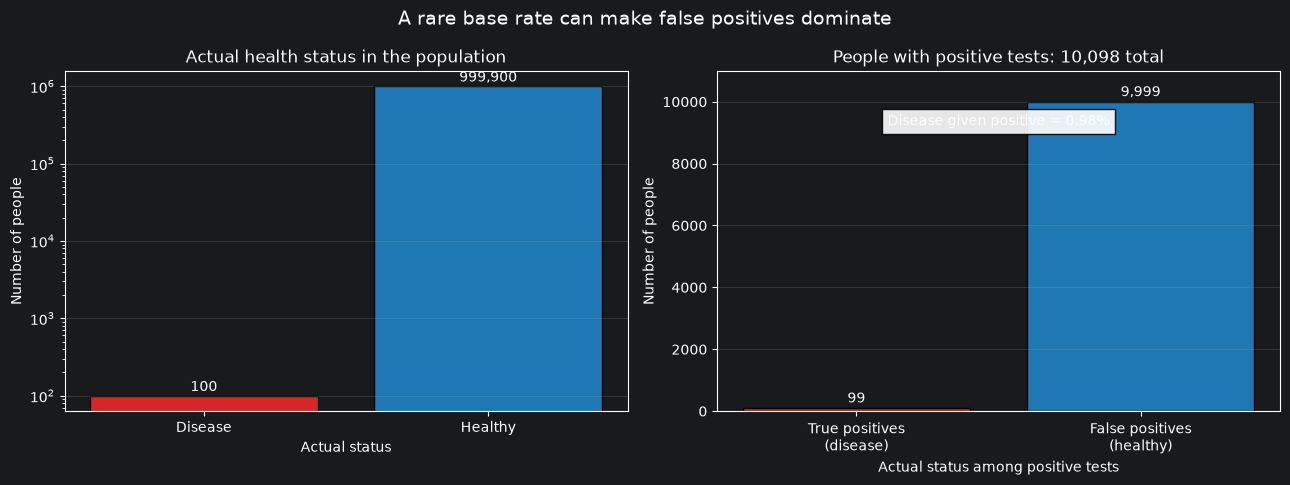

In [2]:
population_size: int = 1_000_000
disease_count: int = 100
healthy_count: int = 999_900
true_positive_count: int = 99
false_negative_count: int = 1
false_positive_count: int = 9_999
true_negative_count: int = 989_901
positive_count: int = true_positive_count + false_positive_count
posterior_disease: float = true_positive_count / positive_count

assert disease_count + healthy_count == population_size
assert true_positive_count + false_negative_count == disease_count
assert false_positive_count + true_negative_count == healthy_count
assert positive_count == 10_098

fig, axes = plt.subplots(1, 2, figsize=(13, 4.9))
status_labels: list[str] = ["Disease", "Healthy"]
status_counts: np.ndarray = np.array([disease_count, healthy_count])
axes[0].bar(status_labels, status_counts, color=["tab:red", "tab:blue"], edgecolor="black")
axes[0].set(
    title="Actual health status in the population",
    xlabel="Actual status",
    ylabel="Number of people",
)
axes[0].set_yscale("log")
axes[0].grid(axis="y", alpha=0.25)
for index, value in enumerate(status_counts):
    axes[0].text(index, value * 1.15, f"{value:,}", ha="center", fontsize=10)

positive_labels: list[str] = ["True positives\n(disease)", "False positives\n(healthy)"]
positive_values: np.ndarray = np.array([true_positive_count, false_positive_count])
axes[1].bar(positive_labels, positive_values, color=["tab:red", "tab:blue"], edgecolor="black")
axes[1].set(
    title=f"People with positive tests: {positive_count:,} total",
    xlabel="Actual status among positive tests",
    ylabel="Number of people",
    ylim=(0, 11_000),
)
axes[1].grid(axis="y", alpha=0.25)
for index, value in enumerate(positive_values):
    axes[1].text(index, value + 180, f"{value:,}", ha="center", fontsize=10)
axes[1].text(
    0.5,
    0.84,
    f"Disease given positive = {posterior_disease:.2%}",
    transform=axes[1].transAxes,
    ha="center",
    bbox={"facecolor": "white", "edgecolor": "black", "alpha": 0.9},
)

fig.suptitle("A rare base rate can make false positives dominate", fontsize=14)
fig.tight_layout()
plt.show()

### Why the result is surprising

A positive result feels persuasive because the test correctly classifies $99\%$ of each health-status group. However, accuracy must be combined with the **base rate**, the probability of disease before observing the test:

$$
P(D)=0.01\%.
$$

The healthy population is $9{,}999$ times larger than the diseased population. One percent of that very large healthy group produces many more false positives than the $99$ true positives.

This is the **base-rate effect**: when an event is rare, even a small false-positive rate can strongly affect the interpretation of a positive result.

### Takeaway

Bayes' theorem updates an initial probability using new evidence:

$$
\boxed{
P(D\mid +)
=
\frac{P(+\mid D)P(D)}
{P(+\mid D)P(D)+P(+\mid D^c)P(D^c)}.
}
$$

For the lecture's assumptions:

- prevalence: $1$ in $10{,}000$;
- sensitivity: $99\%$;
- specificity: $99\%$;
- probability of disease given a positive test: approximately $0.98\%$.

A test's sensitivity and specificity do not answer the reverse conditional question by themselves. The disease's base rate must also be included.